# MAPPO Collaboration vs IC3Net Communication — Evaluation

Vergelijking van twee MAPPO-configuraties voor Multi-Agent Resource Allocation in BPM:
- **MAPPO Collaboration**: Agents werken samen aan taken (zonder communicatie)
- **MAPPO IC3Net**: Agents communiceren via IC3Net gating mechanisme

**Metrics**: Cycle Time, Waiting Time, Processing Time, Case Throughput, Reward, Agent Utilization

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Project root
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
})

# Kleuren per config
COLORS = {
    'collaboration': '#1f77b4',  # blauw
    'ic3net': '#ff7f0e',         # oranje
}
LABELS = {
    'collaboration': 'MAPPO Collaboration',
    'ic3net': 'MAPPO + IC3Net',
}

print(f'Project root: {PROJECT_ROOT}')
print('Libraries loaded.')

Project root: /Users/bjornkoemans/Documents/GitHub/master-cope
Libraries loaded.


## 1. Data Laden

Laad training summaries, episode rewards, evaluation rewards en de gedetailleerde log-bestanden.

In [2]:
# ── Pad naar resultaten ──────────────────────────────────────────────
# Pas deze paden aan als je lokale of andere remote results wilt gebruiken
RESULTS_ROOT = PROJECT_ROOT / 'results' / 'remote'

def find_latest_run(config_name: str) -> Path:
    """Vind de meest recente run voor een config."""
    config_dir = RESULTS_ROOT / config_name
    if not config_dir.exists():
        raise FileNotFoundError(f'Results niet gevonden: {config_dir}')
    runs = sorted(config_dir.iterdir())
    if not runs:
        raise FileNotFoundError(f'Geen runs gevonden in: {config_dir}')
    return runs[-1]  # laatste (meest recente) run

collab_dir = find_latest_run('mappo_ic3net_nocomm')
ic3net_dir = find_latest_run('mappo_ic3net')

print(f'Collaboration: {collab_dir.name}')
print(f'IC3Net:        {ic3net_dir.name}')

run_dirs = {'collaboration': collab_dir, 'ic3net': ic3net_dir}

Collaboration: 20260208_221347
IC3Net:        20260209_003518


In [3]:
# ── Training Summary parsen ─────────────────────────────────────────
def parse_training_summary(run_dir: Path) -> dict:
    """Parse training_summary.txt naar een dict."""
    path = run_dir / 'training_summary.txt'
    data = {'episode_rewards': [], 'eval_rewards': []}
    section = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('Total episodes:'):
                data['total_episodes'] = int(line.split(':')[1])
            elif line.startswith('Total timesteps:'):
                data['total_timesteps'] = int(line.split(':')[1])
            elif line.startswith('Total time:'):
                data['total_time_min'] = float(line.split(':')[1].replace('minutes', '').strip())
            elif line.startswith('Best evaluation reward:'):
                data['best_eval_reward'] = float(line.split(':')[1])
            elif line.startswith('Final cumulative reward:'):
                data['final_cum_reward'] = float(line.split(':')[1])
            elif line.startswith('Number of agents:'):
                data['n_agents'] = int(line.split(':')[1])
            elif line.startswith('Episode Rewards:'):
                section = 'episode'
            elif line.startswith('Evaluation Rewards:'):
                section = 'eval'
            elif section == 'episode' and line.startswith('Episode'):
                data['episode_rewards'].append(float(line.split(':')[1]))
            elif section == 'eval' and line.startswith('Eval'):
                data['eval_rewards'].append(float(line.split(':')[1]))
    return data

summaries = {k: parse_training_summary(v) for k, v in run_dirs.items()}

for name, s in summaries.items():
    print(f"\n{'='*50}")
    print(f'{LABELS[name]}')
    print(f"{'='*50}")
    print(f"  Episodes:           {s['total_episodes']}")
    print(f"  Timesteps:          {s['total_timesteps']:,}")
    print(f"  Trainingstijd:      {s['total_time_min']:.1f} min")
    print(f"  Best eval reward:   {s['best_eval_reward']:,.0f}")
    print(f"  Mean train reward:  {np.mean(s['episode_rewards']):,.0f}")
    print(f"  Mean eval reward:   {np.mean(s['eval_rewards']):,.0f}")


MAPPO Collaboration
  Episodes:           25
  Timesteps:          1,562,761
  Trainingstijd:      141.2 min
  Best eval reward:   -1,879,963
  Mean train reward:  -1,986,343
  Mean eval reward:   -1,992,774

MAPPO + IC3Net
  Episodes:           25
  Timesteps:          1,562,738
  Trainingstijd:      84.7 min
  Best eval reward:   -1,470,271
  Mean train reward:  -1,492,927
  Mean eval reward:   -1,477,055


## 2. Training Rewards — Leercurve

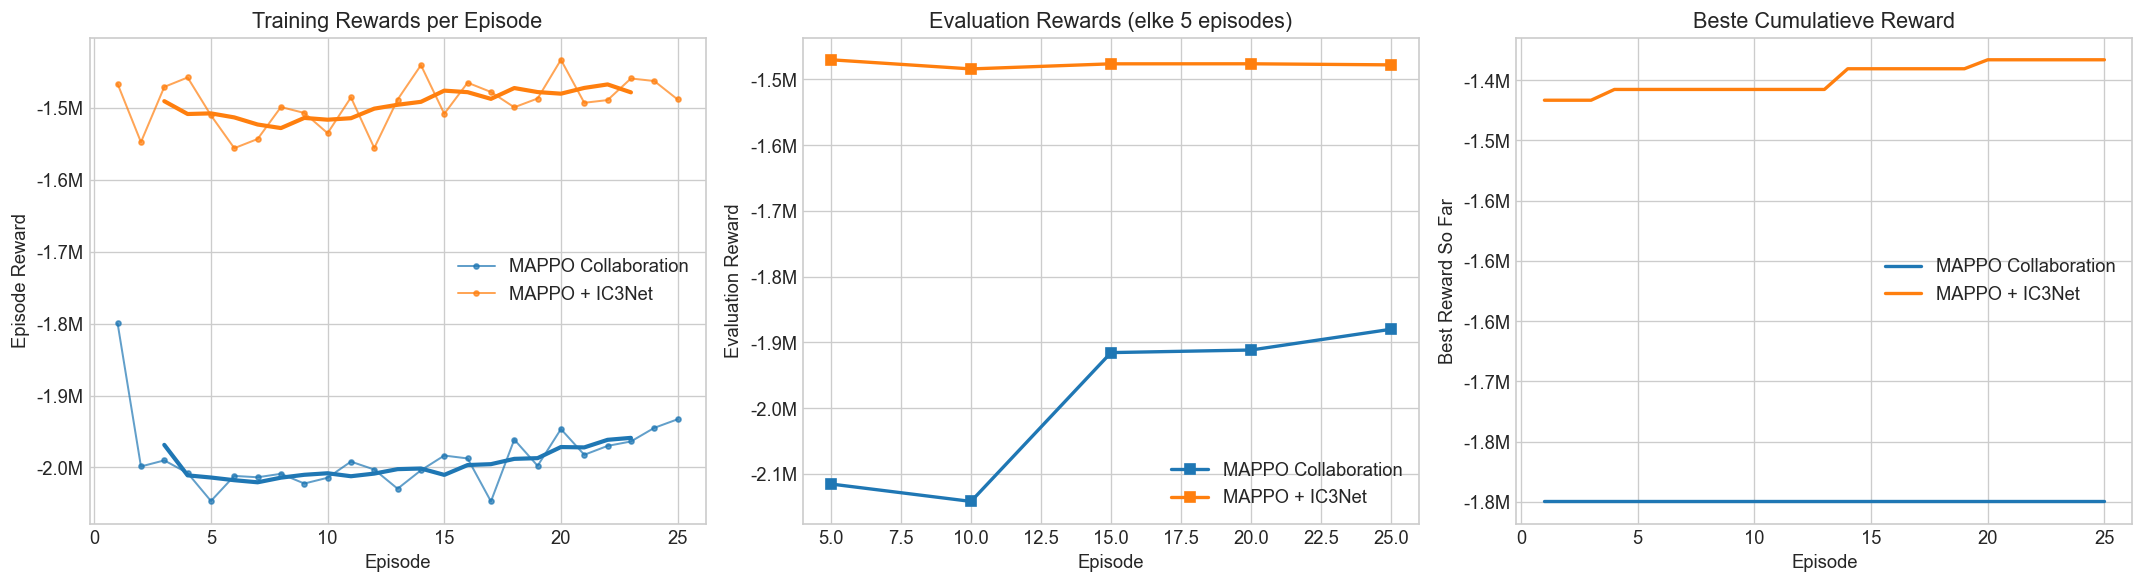

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 2a. Episode rewards ──
ax = axes[0]
for name, s in summaries.items():
    rewards = s['episode_rewards']
    episodes = range(1, len(rewards) + 1)
    ax.plot(episodes, rewards, '-o', color=COLORS[name], label=LABELS[name],
            markersize=3, linewidth=1.2, alpha=0.7)
    # Moving average (window=5)
    if len(rewards) >= 5:
        ma = pd.Series(rewards).rolling(5, center=True).mean()
        ax.plot(episodes, ma, '-', color=COLORS[name], linewidth=2.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Reward')
ax.set_title('Training Rewards per Episode')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# ── 2b. Evaluation rewards ──
ax = axes[1]
for name, s in summaries.items():
    evals = s['eval_rewards']
    eval_episodes = [5 * (i + 1) for i in range(len(evals))]
    ax.plot(eval_episodes, evals, '-s', color=COLORS[name], label=LABELS[name],
            markersize=6, linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Evaluation Reward')
ax.set_title('Evaluation Rewards (elke 5 episodes)')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# ── 2c. Best-so-far ──
ax = axes[2]
for name, s in summaries.items():
    rewards = s['episode_rewards']
    best_so_far = np.maximum.accumulate(rewards)
    episodes = range(1, len(rewards) + 1)
    ax.plot(episodes, best_so_far, '-', color=COLORS[name], label=LABELS[name], linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Best Reward So Far')
ax.set_title('Beste Cumulatieve Reward')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

## 3. Log-based Process Metrics Laden

Laad alle gedetailleerde log CSV-bestanden en bereken per-taak en per-case metrics.

In [5]:
def load_all_logs(run_dir: Path) -> pd.DataFrame:
    """Laad alle log CSVs van een run en concateneer ze met episode nummer."""
    logs_dir = run_dir / 'logs'
    log_files = sorted(logs_dir.glob('log_*.csv'))
    
    frames = []
    for i, lf in enumerate(log_files):
        df = pd.read_csv(lf)
        df['episode'] = i
        df['log_file'] = lf.name
        frames.append(df)
    
    combined = pd.concat(frames, ignore_index=True)
    
    # Parse timestamps
    time_cols = ['case_open_time', 'case_completed_time',
                 'task_assigned_time', 'task_started_time', 'task_completed_time']
    for col in time_cols:
        combined[col] = pd.to_datetime(combined[col], format='ISO8601', errors='coerce')
    
    # Bereken task-level metrics (in minuten)
    combined['waiting_time'] = (combined['task_started_time'] - combined['task_assigned_time']).dt.total_seconds() / 60
    combined['processing_time'] = (combined['task_completed_time'] - combined['task_started_time']).dt.total_seconds() / 60
    combined['cycle_time'] = (combined['task_completed_time'] - combined['task_assigned_time']).dt.total_seconds() / 60
    
    return combined

def compute_case_metrics(logs_df: pd.DataFrame) -> pd.DataFrame:
    """Bereken case-level metrics vanuit task-level logs."""
    cases = logs_df.groupby(['episode', 'case_id']).agg(
        case_open_time=('case_open_time', 'first'),
        case_completed_time=('case_completed_time', 'first'),
        n_tasks=('task_id', 'count'),
        total_waiting=('waiting_time', 'sum'),
        total_processing=('processing_time', 'sum'),
        total_cycle=('cycle_time', 'sum'),
        mean_waiting=('waiting_time', 'mean'),
        mean_processing=('processing_time', 'mean'),
        mean_cycle=('cycle_time', 'mean'),
        n_collab_tasks=('task_agents_required', lambda x: (x > 1).sum()),
    ).reset_index()
    
    # Case throughput = totale doorlooptijd van case
    cases['case_throughput'] = (cases['case_completed_time'] - cases['case_open_time']).dt.total_seconds() / 60
    
    return cases

# Laad data
logs = {}
case_metrics = {}
for name, d in run_dirs.items():
    print(f'Laden: {LABELS[name]}...')
    logs[name] = load_all_logs(d)
    case_metrics[name] = compute_case_metrics(logs[name])
    print(f'  {len(logs[name]):,} taken  |  {len(case_metrics[name]):,} cases  |  {logs[name]["episode"].nunique()} episodes')

print('\nData geladen!')

Laden: MAPPO Collaboration...
  3,125,250 taken  |  300,450 cases  |  50 episodes
Laden: MAPPO + IC3Net...
  3,125,250 taken  |  300,450 cases  |  50 episodes

Data geladen!


## 4. Case Throughput (Doorlooptijd)

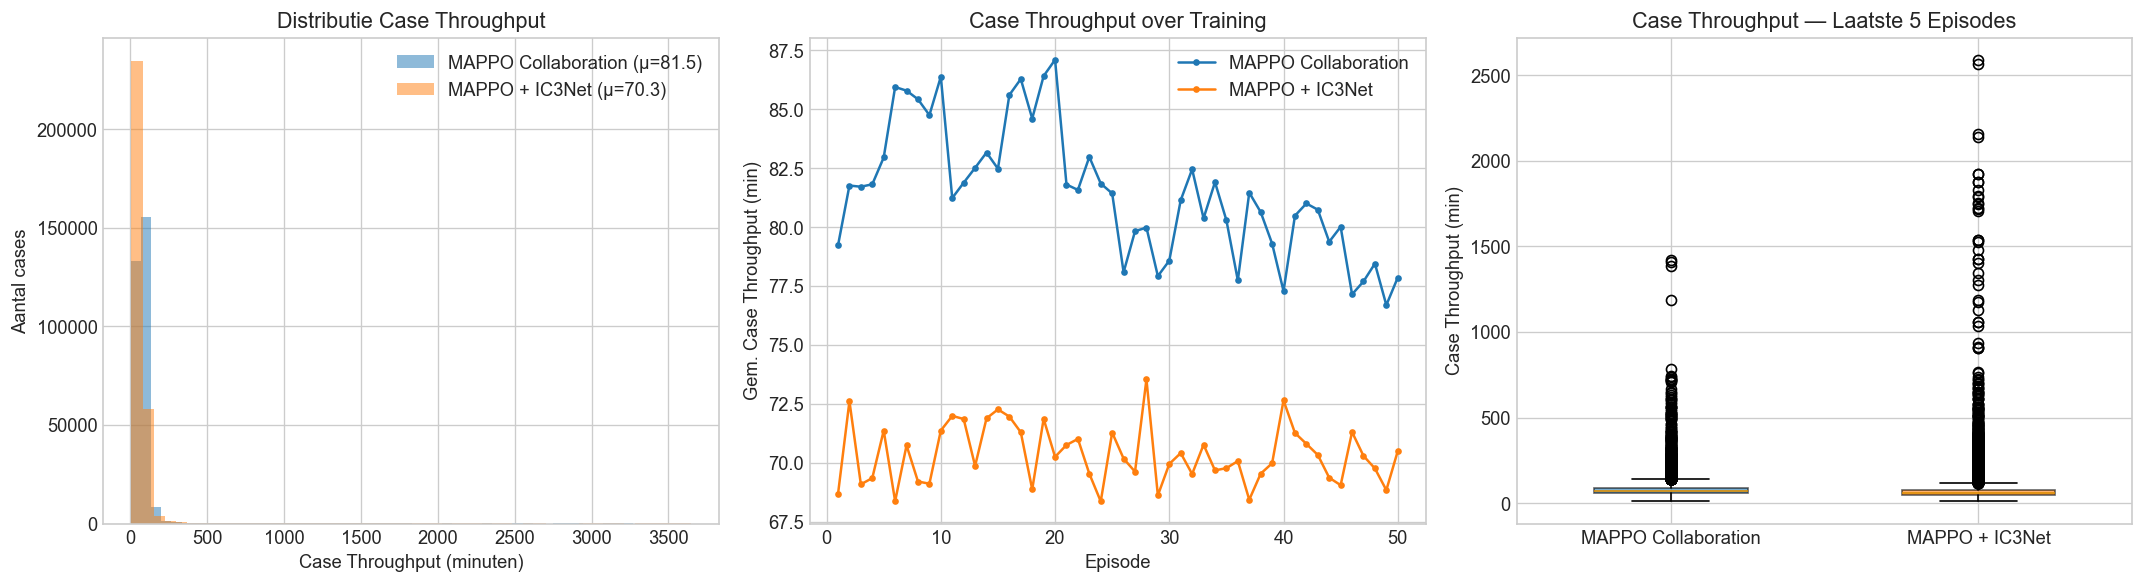


Case Throughput (minuten) — Laatste 5 episodes:
  MAPPO Collaboration      : mean=77.6  median=72.5  std=39.2
  MAPPO + IC3Net           : mean=70.1  median=61.2  std=67.7


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 4a. Distributie case throughput (alle episodes) ──
ax = axes[0]
for name in ['collaboration', 'ic3net']:
    vals = case_metrics[name]['case_throughput'].dropna()
    ax.hist(vals, bins=50, alpha=0.5, color=COLORS[name], label=f"{LABELS[name]} (μ={vals.mean():.1f})")
ax.set_xlabel('Case Throughput (minuten)')
ax.set_ylabel('Aantal cases')
ax.set_title('Distributie Case Throughput')
ax.legend()

# ── 4b. Gemiddelde case throughput per episode ──
ax = axes[1]
for name in ['collaboration', 'ic3net']:
    ep_means = case_metrics[name].groupby('episode')['case_throughput'].mean()
    ax.plot(ep_means.index + 1, ep_means.values, '-o', color=COLORS[name],
            label=LABELS[name], markersize=3, linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Gem. Case Throughput (min)')
ax.set_title('Case Throughput over Training')
ax.legend()

# ── 4c. Box plot vergelijking (laatste 5 episodes) ──
ax = axes[2]
last_5_data = []
last_5_labels = []
for name in ['collaboration', 'ic3net']:
    max_ep = case_metrics[name]['episode'].max()
    last_5 = case_metrics[name][case_metrics[name]['episode'] >= max_ep - 4]['case_throughput'].dropna()
    last_5_data.append(last_5.values)
    last_5_labels.append(LABELS[name])

bp = ax.boxplot(last_5_data, labels=last_5_labels, patch_artist=True, widths=0.5)
for patch, name in zip(bp['boxes'], ['collaboration', 'ic3net']):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.6)
ax.set_ylabel('Case Throughput (min)')
ax.set_title('Case Throughput — Laatste 5 Episodes')

plt.tight_layout()
plt.show()

# Statistieken
print('\nCase Throughput (minuten) — Laatste 5 episodes:')
for name in ['collaboration', 'ic3net']:
    max_ep = case_metrics[name]['episode'].max()
    vals = case_metrics[name][case_metrics[name]['episode'] >= max_ep - 4]['case_throughput']
    print(f"  {LABELS[name]:25s}: mean={vals.mean():.1f}  median={vals.median():.1f}  std={vals.std():.1f}")

## 5. Waiting Time & Processing Time

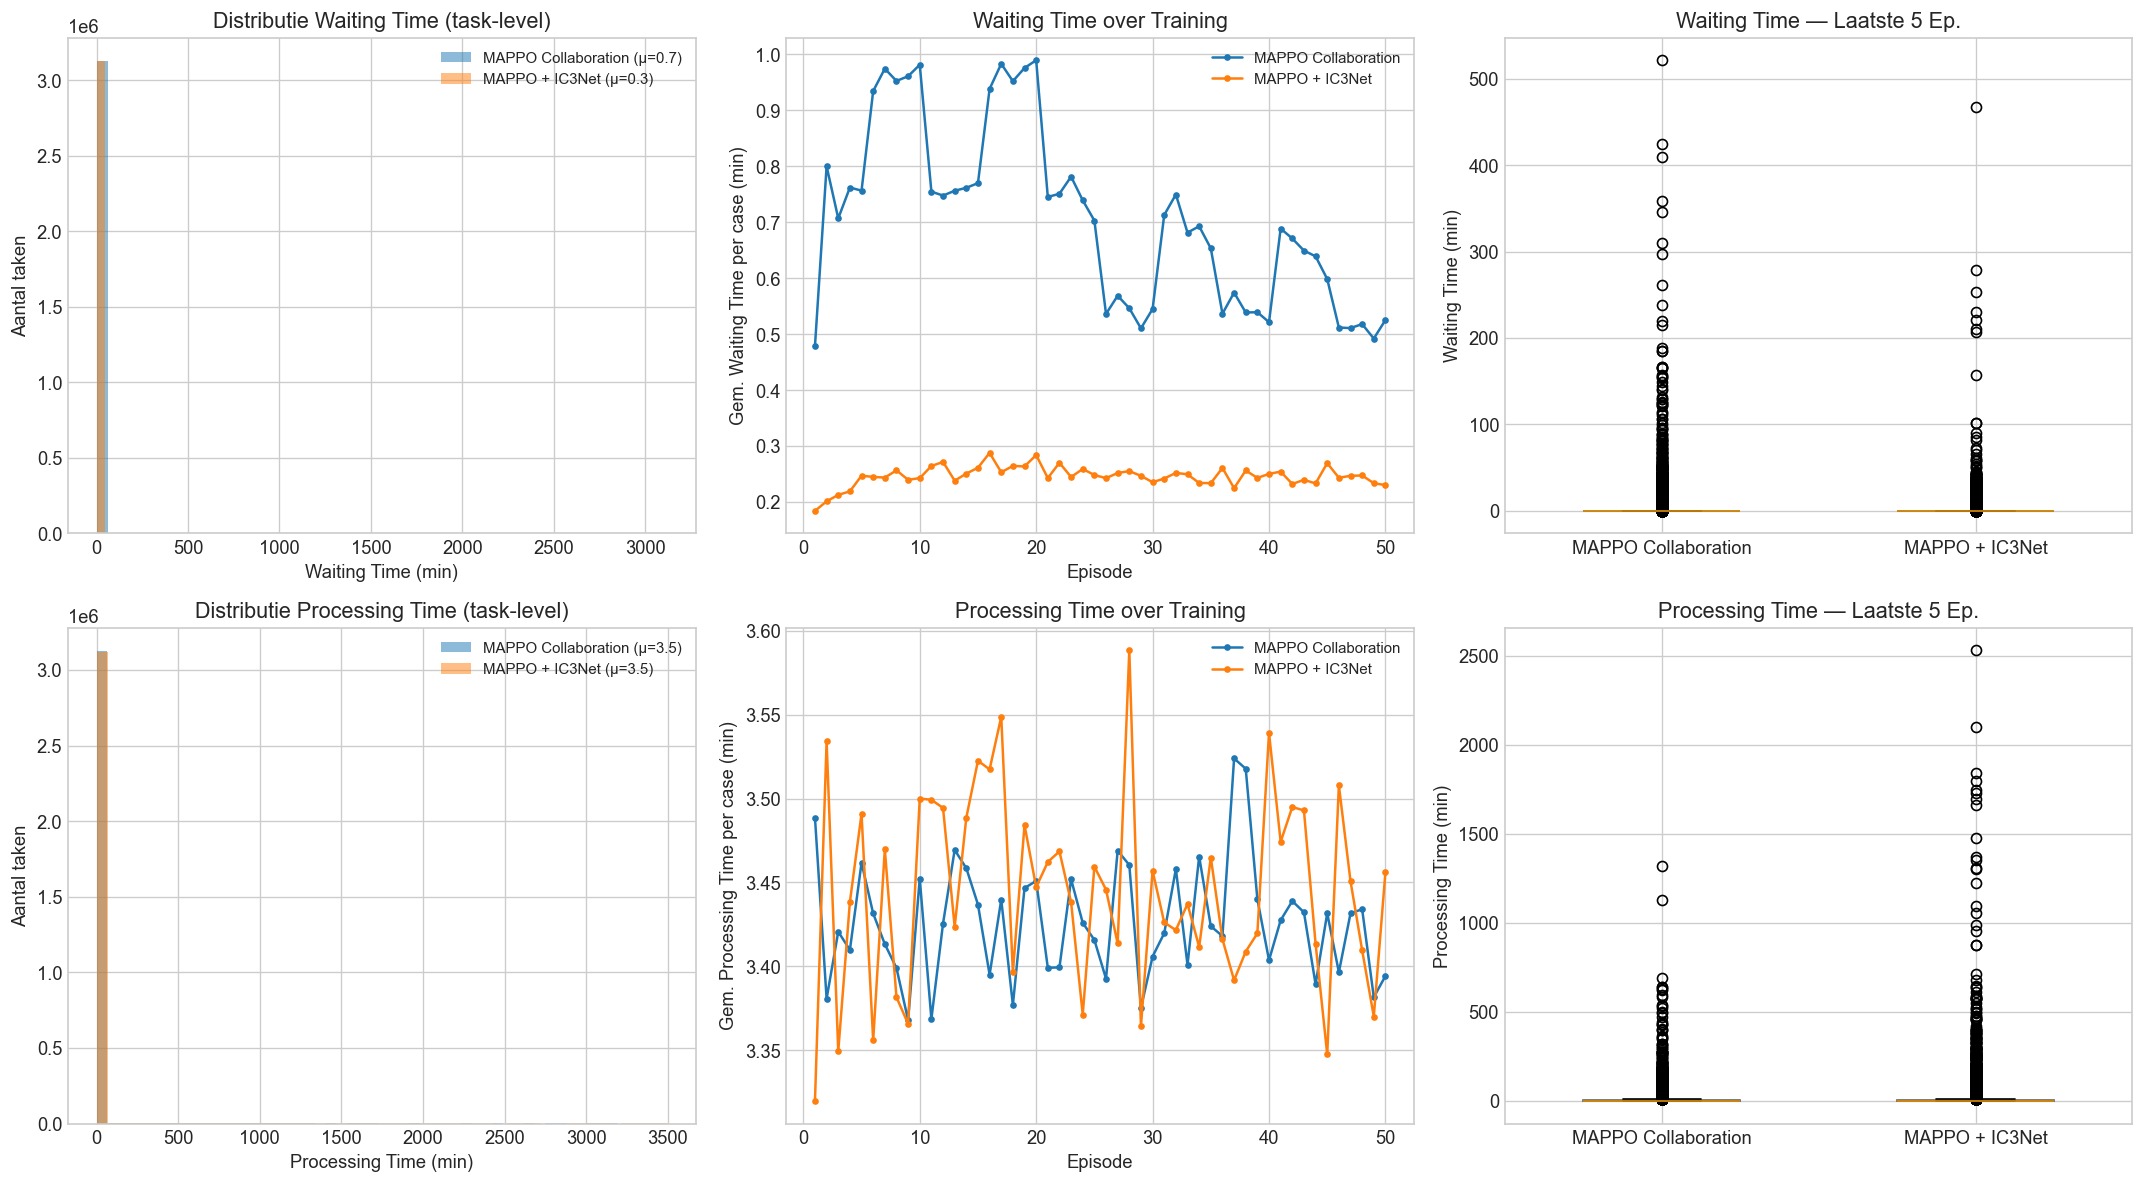

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, metric in enumerate(['waiting_time', 'processing_time']):
    metric_label = 'Waiting Time' if metric == 'waiting_time' else 'Processing Time'
    
    # ── Distributie (task-level) ──
    ax = axes[row, 0]
    for name in ['collaboration', 'ic3net']:
        vals = logs[name][metric].dropna()
        vals = vals[vals >= 0]  # filter negatief
        ax.hist(vals, bins=50, alpha=0.5, color=COLORS[name],
                label=f"{LABELS[name]} (μ={vals.mean():.1f})")
    ax.set_xlabel(f'{metric_label} (min)')
    ax.set_ylabel('Aantal taken')
    ax.set_title(f'Distributie {metric_label} (task-level)')
    ax.legend(fontsize=9)
    
    # ── Trend per episode (gemiddeld per case) ──
    ax = axes[row, 1]
    case_col = f'mean_{metric.replace("_time", "")}'
    for name in ['collaboration', 'ic3net']:
        ep_means = case_metrics[name].groupby('episode')[case_col].mean()
        ax.plot(ep_means.index + 1, ep_means.values, '-o', color=COLORS[name],
                label=LABELS[name], markersize=3, linewidth=1.5)
    ax.set_xlabel('Episode')
    ax.set_ylabel(f'Gem. {metric_label} per case (min)')
    ax.set_title(f'{metric_label} over Training')
    ax.legend(fontsize=9)
    
    # ── Box plot laatste 5 episodes ──
    ax = axes[row, 2]
    box_data = []
    box_labels = []
    for name in ['collaboration', 'ic3net']:
        max_ep = logs[name]['episode'].max()
        vals = logs[name][logs[name]['episode'] >= max_ep - 4][metric].dropna()
        vals = vals[vals >= 0]
        box_data.append(vals.values)
        box_labels.append(LABELS[name])
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5)
    for patch, n in zip(bp['boxes'], ['collaboration', 'ic3net']):
        patch.set_facecolor(COLORS[n])
        patch.set_alpha(0.6)
    ax.set_ylabel(f'{metric_label} (min)')
    ax.set_title(f'{metric_label} — Laatste 5 Ep.')

plt.tight_layout()
plt.show()

## 6. Cycle Time (Task-level)

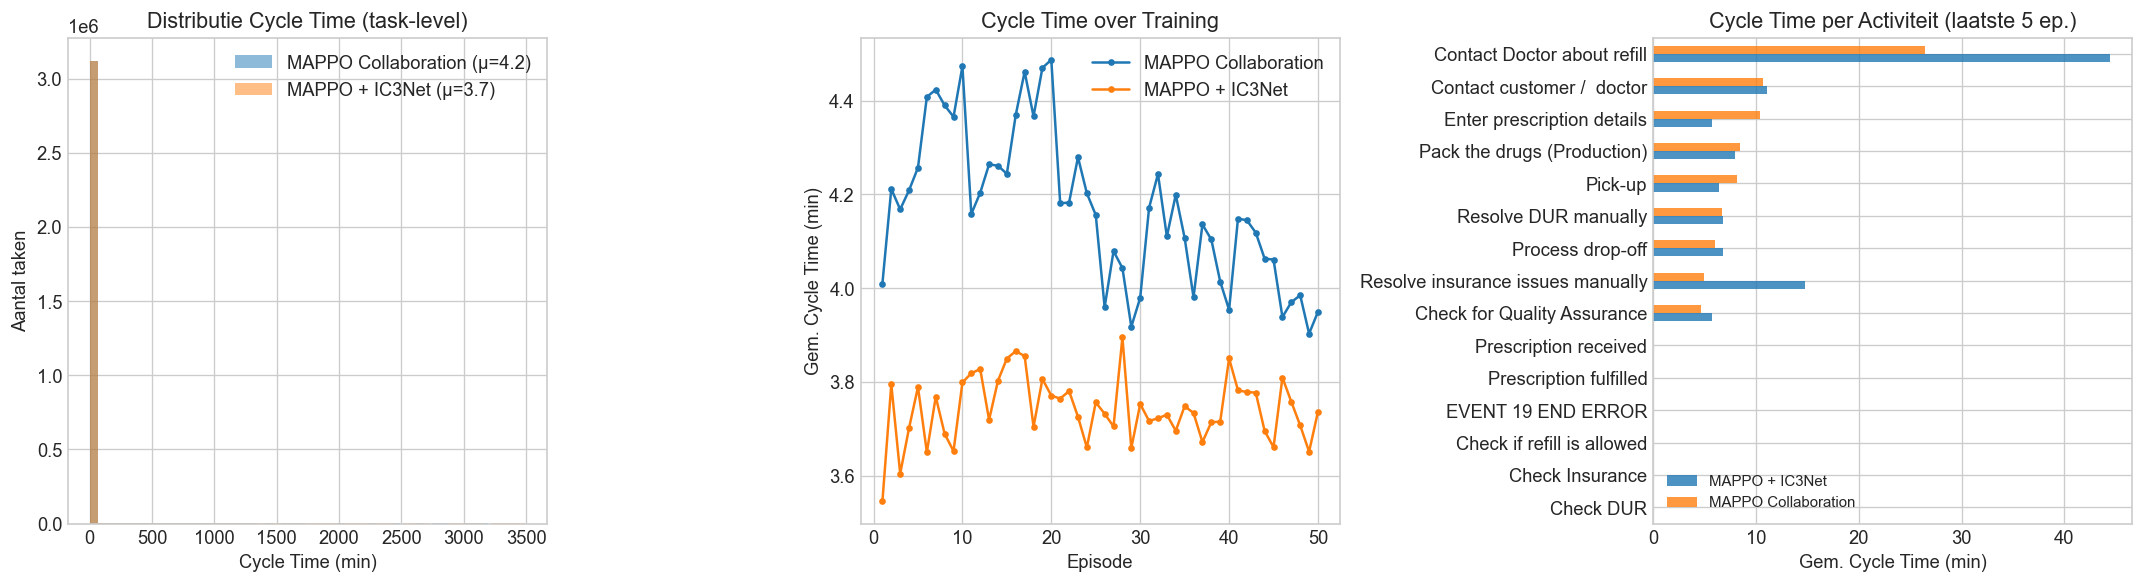

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 6a. Distributie cycle time ──
ax = axes[0]
for name in ['collaboration', 'ic3net']:
    vals = logs[name]['cycle_time'].dropna()
    vals = vals[vals >= 0]
    ax.hist(vals, bins=50, alpha=0.5, color=COLORS[name],
            label=f"{LABELS[name]} (μ={vals.mean():.1f})")
ax.set_xlabel('Cycle Time (min)')
ax.set_ylabel('Aantal taken')
ax.set_title('Distributie Cycle Time (task-level)')
ax.legend()

# ── 6b. Per episode ──
ax = axes[1]
for name in ['collaboration', 'ic3net']:
    ep_means = logs[name].groupby('episode')['cycle_time'].mean()
    ax.plot(ep_means.index + 1, ep_means.values, '-o', color=COLORS[name],
            label=LABELS[name], markersize=3, linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Gem. Cycle Time (min)')
ax.set_title('Cycle Time over Training')
ax.legend()

# ── 6c. Per activiteit (laatste 5 episodes) ──
ax = axes[2]
comparison = []
for name in ['collaboration', 'ic3net']:
    max_ep = logs[name]['episode'].max()
    last = logs[name][logs[name]['episode'] >= max_ep - 4].copy()
    last_grouped = last.groupby('task_name')['cycle_time'].mean().reset_index()
    last_grouped['config'] = LABELS[name]
    comparison.append(last_grouped)

comp_df = pd.concat(comparison)
# Filter out artificial tasks
comp_df = comp_df[~comp_df['task_name'].str.startswith('artificial')]

pivot = comp_df.pivot(index='task_name', columns='config', values='cycle_time').sort_values(
    by=LABELS['collaboration'], ascending=True)
pivot.plot(kind='barh', ax=ax, color=[COLORS['collaboration'], COLORS['ic3net']], alpha=0.8)
ax.set_xlabel('Gem. Cycle Time (min)')
ax.set_ylabel('')
ax.set_title('Cycle Time per Activiteit (laatste 5 ep.)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Agent Utilization

MAPPO Collaboration: 200 agent-episode records
MAPPO + IC3Net: 200 agent-episode records


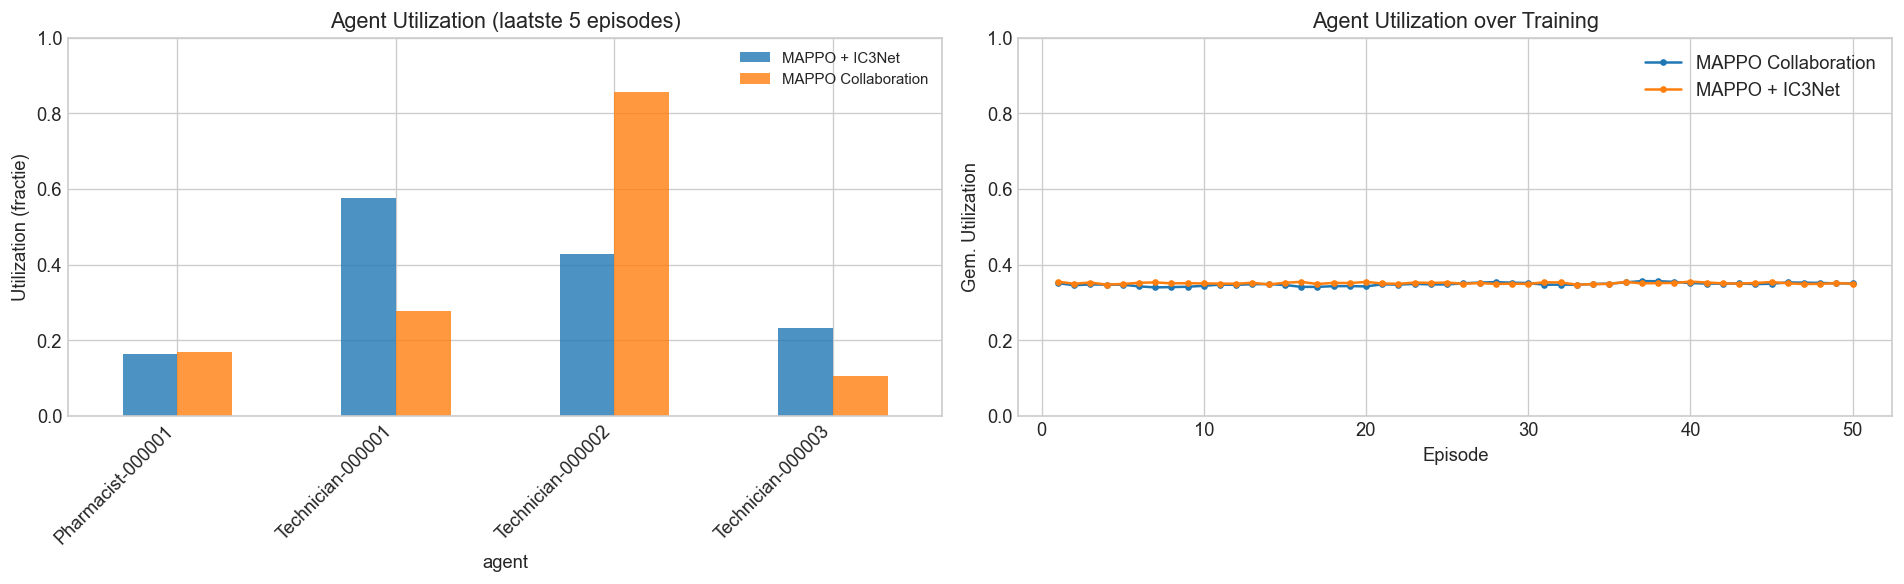

In [9]:
def compute_agent_utilization(logs_df: pd.DataFrame) -> pd.DataFrame:
    """Bereken agent utilization: fractie van de tijd dat een agent bezig is."""
    results = []
    
    for episode, ep_df in logs_df.groupby('episode'):
        sim_start = ep_df['task_assigned_time'].min()
        sim_end = ep_df['task_completed_time'].max()
        sim_duration = (sim_end - sim_start).total_seconds() / 60  # minuten
        
        if sim_duration <= 0:
            continue
        
        # Explode multi-agent taken
        rows = []
        for _, row in ep_df.iterrows():
            agents = str(row['task_agent_name']).split(',')
            for agent in agents:
                agent = agent.strip()
                if agent.startswith('artificial') or agent.startswith('Pharmacy System'):
                    continue
                proc_time = row['processing_time']
                if pd.notna(proc_time) and proc_time > 0:
                    rows.append({'agent': agent, 'processing_time': proc_time})
        
        if not rows:
            continue
        
        agent_df = pd.DataFrame(rows)
        agent_totals = agent_df.groupby('agent')['processing_time'].sum()
        
        for agent, total_proc in agent_totals.items():
            results.append({
                'episode': episode,
                'agent': agent,
                'total_processing_min': total_proc,
                'sim_duration_min': sim_duration,
                'utilization': min(total_proc / sim_duration, 1.0),
            })
    
    return pd.DataFrame(results)

util = {}
for name in ['collaboration', 'ic3net']:
    util[name] = compute_agent_utilization(logs[name])
    print(f"{LABELS[name]}: {len(util[name])} agent-episode records")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 7a. Utilization per agent type (laatste 5 episodes) ──
ax = axes[0]
util_comparison = []
for name in ['collaboration', 'ic3net']:
    max_ep = util[name]['episode'].max()
    last = util[name][util[name]['episode'] >= max_ep - 4]
    agent_util = last.groupby('agent')['utilization'].mean().reset_index()
    agent_util['config'] = LABELS[name]
    util_comparison.append(agent_util)

util_comp = pd.concat(util_comparison)
pivot_util = util_comp.pivot(index='agent', columns='config', values='utilization')
pivot_util.plot(kind='bar', ax=ax, color=[COLORS['collaboration'], COLORS['ic3net']], alpha=0.8)
ax.set_ylabel('Utilization (fractie)')
ax.set_title('Agent Utilization (laatste 5 episodes)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

# ── 7b. Utilization trend over episodes ──
ax = axes[1]
for name in ['collaboration', 'ic3net']:
    ep_util = util[name].groupby('episode')['utilization'].mean()
    ax.plot(ep_util.index + 1, ep_util.values, '-o', color=COLORS[name],
            label=LABELS[name], markersize=3, linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Gem. Utilization')
ax.set_title('Agent Utilization over Training')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 8. Collaborative Task Analyse

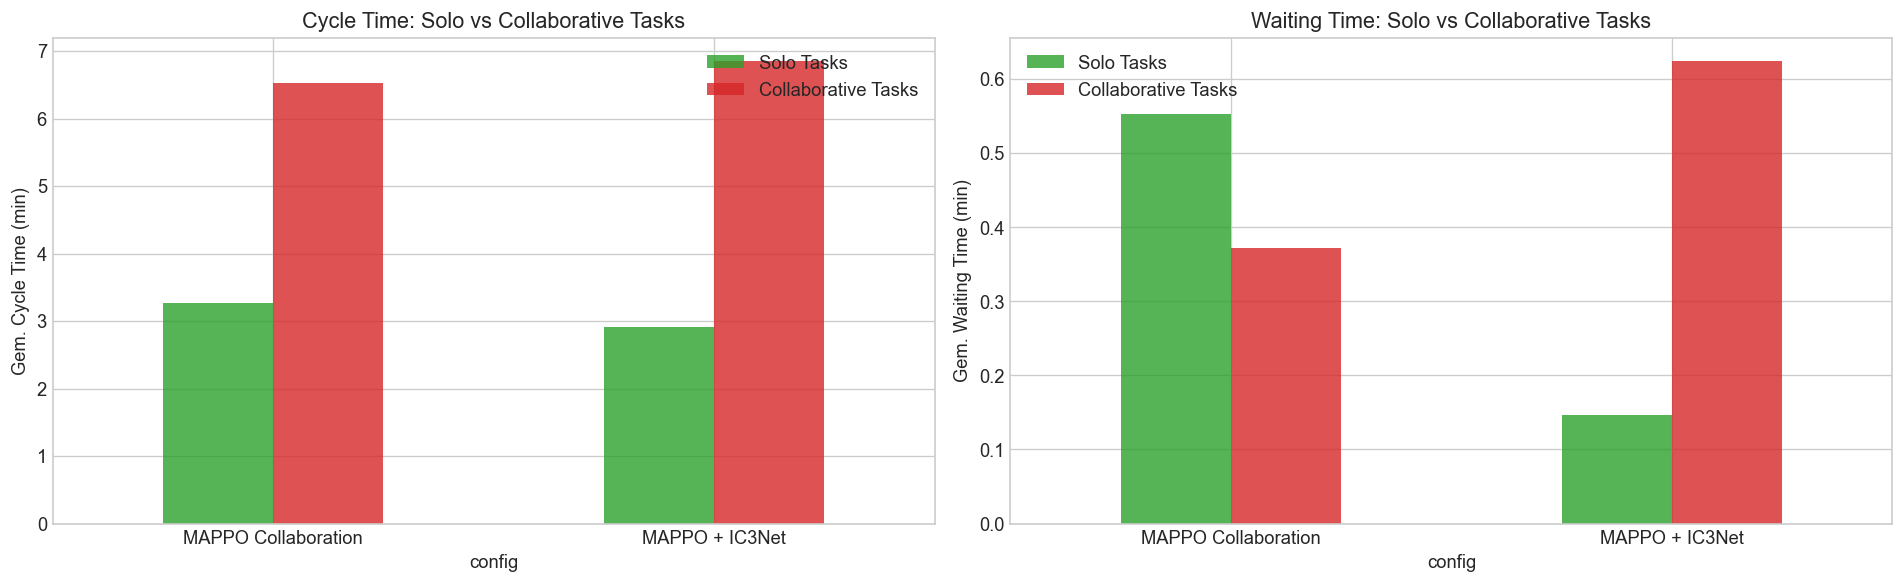

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 8a. Cycle time: solo vs collab taken ──
ax = axes[0]
bar_data = []
for name in ['collaboration', 'ic3net']:
    max_ep = logs[name]['episode'].max()
    last = logs[name][logs[name]['episode'] >= max_ep - 4].copy()
    last = last[~last['task_name'].str.startswith('artificial')]
    
    solo = last[last['task_agents_required'] == 1]['cycle_time'].mean()
    collab = last[last['task_agents_required'] > 1]['cycle_time'].mean()
    bar_data.append({'config': LABELS[name], 'Solo Tasks': solo, 'Collaborative Tasks': collab})

bar_df = pd.DataFrame(bar_data).set_index('config')
bar_df.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728'], alpha=0.8)
ax.set_ylabel('Gem. Cycle Time (min)')
ax.set_title('Cycle Time: Solo vs Collaborative Tasks')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()

# ── 8b. Waiting time: solo vs collab taken ──
ax = axes[1]
bar_data = []
for name in ['collaboration', 'ic3net']:
    max_ep = logs[name]['episode'].max()
    last = logs[name][logs[name]['episode'] >= max_ep - 4].copy()
    last = last[~last['task_name'].str.startswith('artificial')]
    
    solo = last[last['task_agents_required'] == 1]['waiting_time'].mean()
    collab = last[last['task_agents_required'] > 1]['waiting_time'].mean()
    bar_data.append({'config': LABELS[name], 'Solo Tasks': solo, 'Collaborative Tasks': collab})

bar_df = pd.DataFrame(bar_data).set_index('config')
bar_df.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728'], alpha=0.8)
ax.set_ylabel('Gem. Waiting Time (min)')
ax.set_title('Waiting Time: Solo vs Collaborative Tasks')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()

plt.tight_layout()
plt.show()

## 9. Samenvattende Vergelijkingstabel

In [11]:
# Bereken samenvattende statistieken op basis van laatste 5 episodes
summary_rows = []

for name in ['collaboration', 'ic3net']:
    s = summaries[name]
    
    # Laatste 5 training episodes
    last_5_rewards = s['episode_rewards'][-5:]
    
    # Case metrics laatste 5 episodes
    max_ep = case_metrics[name]['episode'].max()
    last_cases = case_metrics[name][case_metrics[name]['episode'] >= max_ep - 4]
    
    # Task metrics laatste 5 episodes
    max_ep_t = logs[name]['episode'].max()
    last_tasks = logs[name][logs[name]['episode'] >= max_ep_t - 4]
    last_tasks = last_tasks[~last_tasks['task_name'].str.startswith('artificial')]
    
    # Agent utilization laatste 5 episodes
    max_ep_u = util[name]['episode'].max()
    last_util = util[name][util[name]['episode'] >= max_ep_u - 4]
    
    row = {
        'Config': LABELS[name],
        'Mean Train Reward': f"{np.mean(last_5_rewards):,.0f}",
        'Best Eval Reward': f"{s['best_eval_reward']:,.0f}",
        'Mean Eval Reward': f"{np.mean(s['eval_rewards']):,.0f}",
        'Case Throughput (min)': f"{last_cases['case_throughput'].mean():.1f} ± {last_cases['case_throughput'].std():.1f}",
        'Cycle Time (min)': f"{last_tasks['cycle_time'].mean():.1f} ± {last_tasks['cycle_time'].std():.1f}",
        'Waiting Time (min)': f"{last_tasks['waiting_time'].mean():.2f} ± {last_tasks['waiting_time'].std():.2f}",
        'Processing Time (min)': f"{last_tasks['processing_time'].mean():.1f} ± {last_tasks['processing_time'].std():.1f}",
        'Agent Utilization': f"{last_util['utilization'].mean():.3f} ± {last_util['utilization'].std():.3f}",
        'Training Time (min)': f"{s['total_time_min']:.1f}",
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Config').T
print('\n' + '='*70)
print('  SAMENVATTENDE VERGELIJKING (laatste 5 episodes)')
print('='*70)
display(summary_df)


  SAMENVATTENDE VERGELIJKING (laatste 5 episodes)


Config,MAPPO Collaboration,MAPPO + IC3Net
Mean Train Reward,"-1,958,777","-1,478,296"
Best Eval Reward,"-1,879,963","-1,470,271"
Mean Eval Reward,"-1,992,774","-1,477,055"
Case Throughput (min),77.6 ± 39.2,70.1 ± 67.7
Cycle Time (min),3.9 ± 9.2,3.7 ± 15.7
Waiting Time (min),0.51 ± 3.56,0.25 ± 2.15
Processing Time (min),3.4 ± 8.3,3.5 ± 15.5
Agent Utilization,0.352 ± 0.306,0.350 ± 0.167
Training Time (min),141.2,84.7


## 10. Statistische Significantie

In [12]:
from scipy import stats

print('Welch t-test: MAPPO Collaboration vs MAPPO + IC3Net')
print('(Laatste 5 episodes, two-sided)')
print('='*65)

metrics_to_test = [
    ('Case Throughput', 'case_throughput', case_metrics),
    ('Mean Cycle Time', 'mean_cycle', case_metrics),
    ('Mean Waiting Time', 'mean_waiting', case_metrics),
    ('Mean Processing Time', 'mean_processing', case_metrics),
]

for label, col, data_dict in metrics_to_test:
    vals_collab = data_dict['collaboration']
    vals_ic3net = data_dict['ic3net']
    
    max_ep_c = vals_collab['episode'].max()
    max_ep_i = vals_ic3net['episode'].max()
    
    a = vals_collab[vals_collab['episode'] >= max_ep_c - 4][col].dropna()
    b = vals_ic3net[vals_ic3net['episode'] >= max_ep_i - 4][col].dropna()
    
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    diff_pct = ((b.mean() - a.mean()) / a.mean()) * 100
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    
    print(f'\n{label}:')
    print(f'  Collab:  {a.mean():.2f} ± {a.std():.2f}  (n={len(a)})')
    print(f'  IC3Net:  {b.mean():.2f} ± {b.std():.2f}  (n={len(b)})')
    print(f'  Verschil: {diff_pct:+.1f}%  |  t={t_stat:.3f}  |  p={p_val:.4f}  |  {sig}')

# Reward t-test
print(f'\nEpisode Reward (laatste 5 episodes):')
a = np.array(summaries['collaboration']['episode_rewards'][-5:])
b = np.array(summaries['ic3net']['episode_rewards'][-5:])
t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
diff_pct = ((b.mean() - a.mean()) / abs(a.mean())) * 100
sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
print(f'  Collab:  {a.mean():,.0f} ± {a.std():,.0f}')
print(f'  IC3Net:  {b.mean():,.0f} ± {b.std():,.0f}')
print(f'  Verschil: {diff_pct:+.1f}%  |  t={t_stat:.3f}  |  p={p_val:.4f}  |  {sig}')

Welch t-test: MAPPO Collaboration vs MAPPO + IC3Net
(Laatste 5 episodes, two-sided)

Case Throughput:
  Collab:  77.57 ± 39.16  (n=30045)
  IC3Net:  70.14 ± 67.68  (n=30045)
  Verschil: -9.6%  |  t=16.470  |  p=0.0000  |  ***

Mean Cycle Time:
  Collab:  3.92 ± 2.49  (n=30045)
  IC3Net:  3.68 ± 4.48  (n=30045)
  Verschil: -6.1%  |  t=8.115  |  p=0.0000  |  ***

Mean Waiting Time:
  Collab:  0.51 ± 1.06  (n=30045)
  IC3Net:  0.24 ± 0.65  (n=30045)
  Verschil: -53.0%  |  t=37.887  |  p=0.0000  |  ***

Mean Processing Time:
  Collab:  3.41 ± 2.25  (n=30045)
  IC3Net:  3.44 ± 4.43  (n=30045)
  Verschil: +0.9%  |  t=-1.093  |  p=0.2745  |  n.s.

Episode Reward (laatste 5 episodes):
  Collab:  -1,958,777 ± 17,700
  IC3Net:  -1,478,296 ± 14,454
  Verschil: +24.5%  |  t=-42.052  |  p=0.0000  |  ***


## 11. Conclusie Dashboard

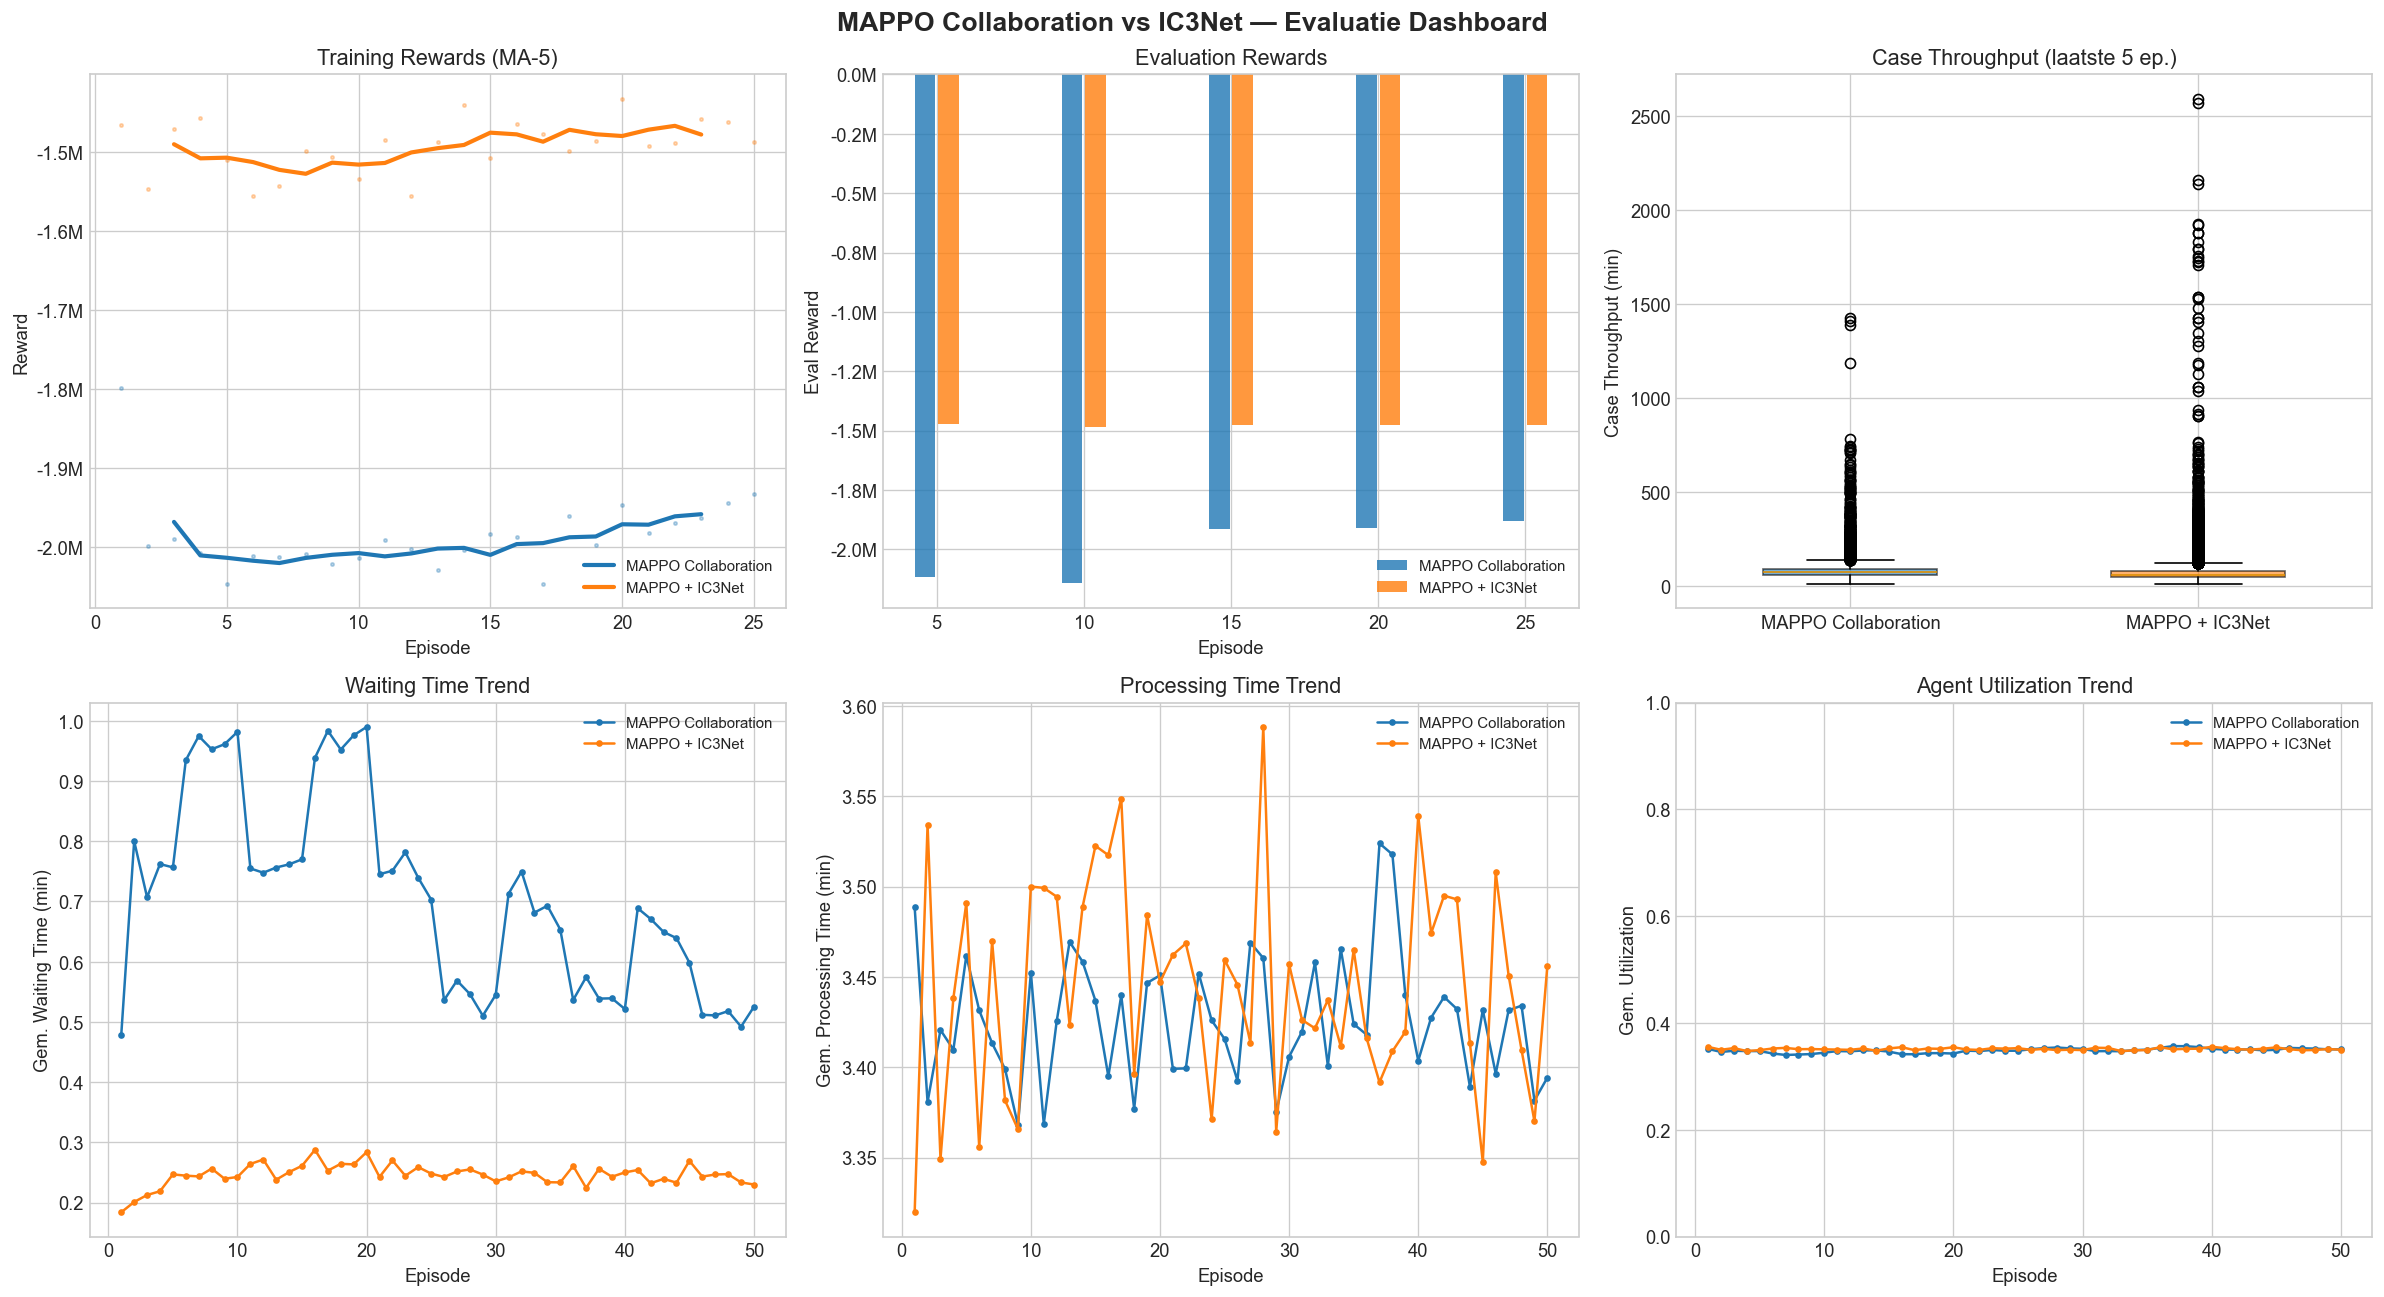


Alle grafieken opgeslagen in analysis/ map.


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('MAPPO Collaboration vs IC3Net — Evaluatie Dashboard', fontsize=16, fontweight='bold')

# ── Panel 1: Reward leercurve ──
ax = axes[0, 0]
for name, s in summaries.items():
    rewards = s['episode_rewards']
    if len(rewards) >= 5:
        ma = pd.Series(rewards).rolling(5, center=True).mean()
        ax.plot(range(1, len(rewards)+1), ma, '-', color=COLORS[name], label=LABELS[name], linewidth=2.5)
    ax.plot(range(1, len(rewards)+1), rewards, '.', color=COLORS[name], alpha=0.3, markersize=4)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('Training Rewards (MA-5)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# ── Panel 2: Eval rewards ──
ax = axes[0, 1]
for name, s in summaries.items():
    evals = s['eval_rewards']
    eval_eps = [5*(i+1) for i in range(len(evals))]
    ax.bar([e + (-0.4 if name=='collaboration' else 0.4) for e in eval_eps], evals,
           width=0.7, color=COLORS[name], alpha=0.8, label=LABELS[name])
ax.set_xlabel('Episode')
ax.set_ylabel('Eval Reward')
ax.set_title('Evaluation Rewards')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# ── Panel 3: Case throughput box ──
ax = axes[0, 2]
data_list = []
labels_list = []
for name in ['collaboration', 'ic3net']:
    max_ep = case_metrics[name]['episode'].max()
    vals = case_metrics[name][case_metrics[name]['episode'] >= max_ep - 4]['case_throughput'].dropna()
    data_list.append(vals.values)
    labels_list.append(LABELS[name])
bp = ax.boxplot(data_list, labels=labels_list, patch_artist=True, widths=0.5)
for patch, n in zip(bp['boxes'], ['collaboration', 'ic3net']):
    patch.set_facecolor(COLORS[n])
    patch.set_alpha(0.6)
ax.set_ylabel('Case Throughput (min)')
ax.set_title('Case Throughput (laatste 5 ep.)')

# ── Panel 4: Waiting time trend ──
ax = axes[1, 0]
for name in ['collaboration', 'ic3net']:
    ep_means = case_metrics[name].groupby('episode')['mean_waiting'].mean()
    ax.plot(ep_means.index+1, ep_means.values, '-o', color=COLORS[name],
            label=LABELS[name], markersize=3, linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Gem. Waiting Time (min)')
ax.set_title('Waiting Time Trend')
ax.legend(fontsize=9)

# ── Panel 5: Processing time trend ──
ax = axes[1, 1]
for name in ['collaboration', 'ic3net']:
    ep_means = case_metrics[name].groupby('episode')['mean_processing'].mean()
    ax.plot(ep_means.index+1, ep_means.values, '-o', color=COLORS[name],
            label=LABELS[name], markersize=3, linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Gem. Processing Time (min)')
ax.set_title('Processing Time Trend')
ax.legend(fontsize=9)

# ── Panel 6: Agent utilization ──
ax = axes[1, 2]
for name in ['collaboration', 'ic3net']:
    ep_util = util[name].groupby('episode')['utilization'].mean()
    ax.plot(ep_util.index+1, ep_util.values, '-o', color=COLORS[name],
            label=LABELS[name], markersize=3, linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Gem. Utilization')
ax.set_title('Agent Utilization Trend')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print('\nAlle grafieken opgeslagen in analysis/ map.')